In [10]:
import tensorflow as tf
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import NearestNeighbors

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


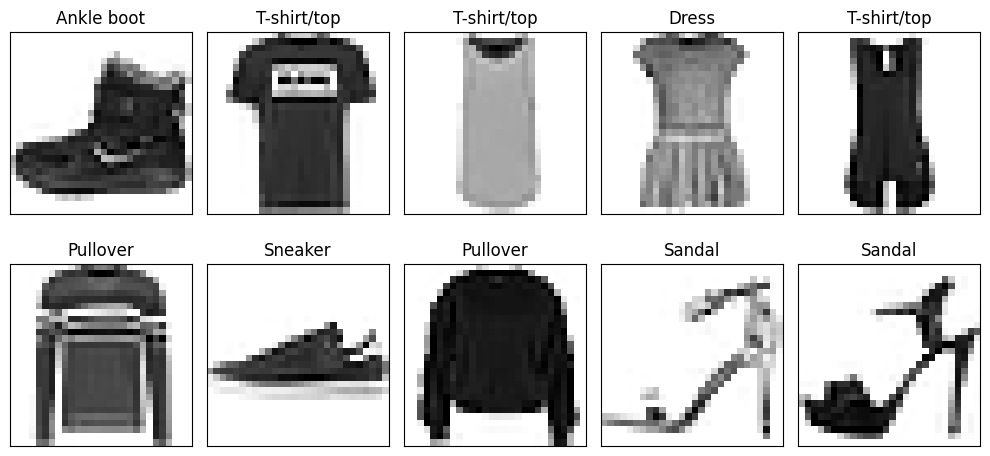

In [ ]:
# Carrega o dataset Fashion MNIST
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (_, _) = fashion_mnist.load_data()

# Lista de nomes das classes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualizar as 10 primeiras imagens com seus rótulos
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[i]])
plt.tight_layout()
plt.show()


In [4]:
print("Dimensionalidade da imagem:", train_images[0].shape)

Dimensionalidade da imagem: (28, 28)


Executando t-SNE... (pode demorar alguns minutos)


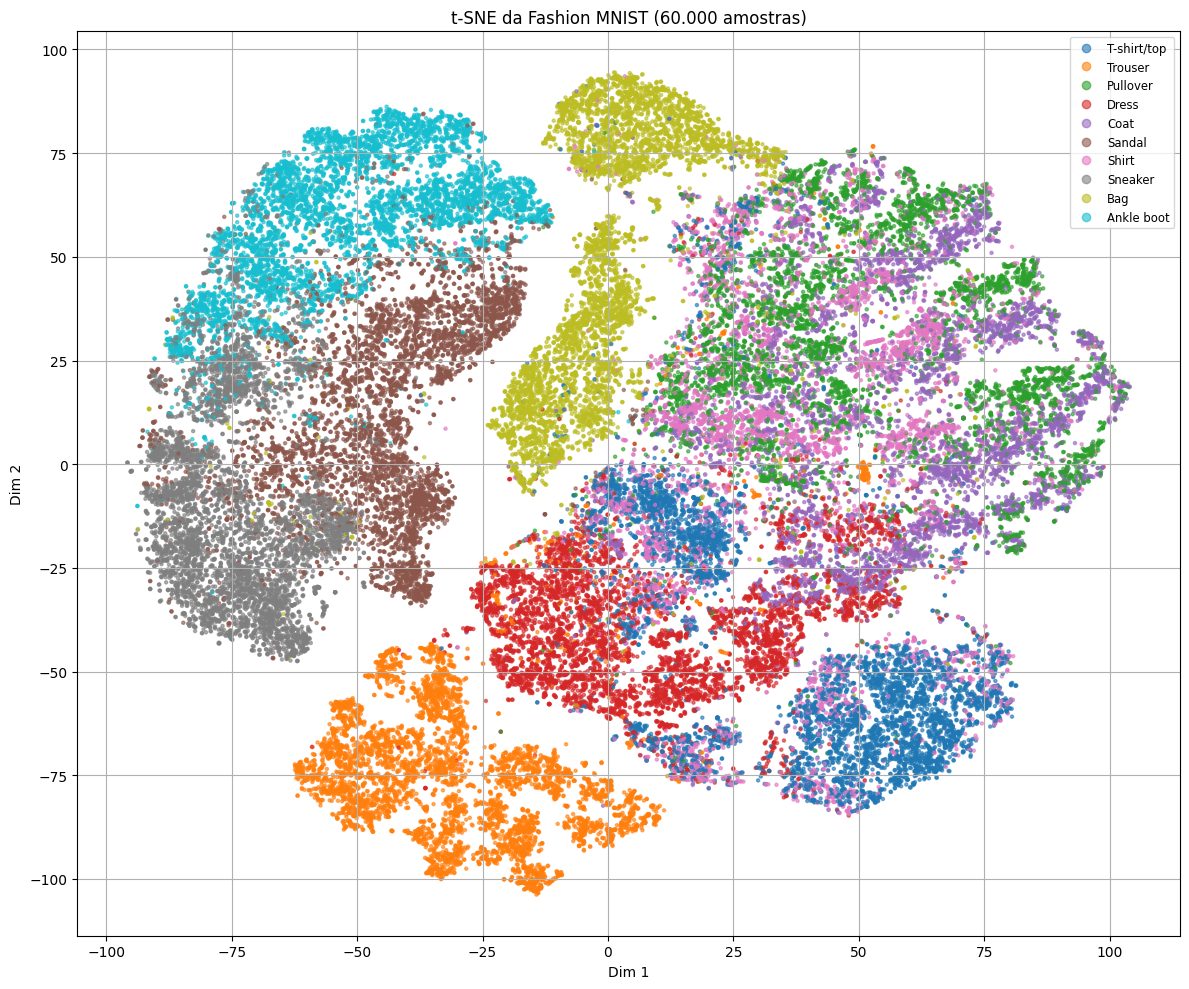

In [8]:
# Redimensiona as imagens para vetores 1D e normaliza
X = train_images.reshape(-1, 28*28) / 255.0
y = train_labels

# Aplica t-SNE com todos os dados
print("Executando t-SNE... (pode demorar alguns minutos)")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

# Lista de nomes das classes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualização
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.6, s=5)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, loc="best", fontsize='small')
plt.title("t-SNE da Fashion MNIST (60.000 amostras)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.tight_layout()
plt.show()

Executando t-SNE... Isso pode demorar alguns minutos.
Calculando vizinhos mais próximos...


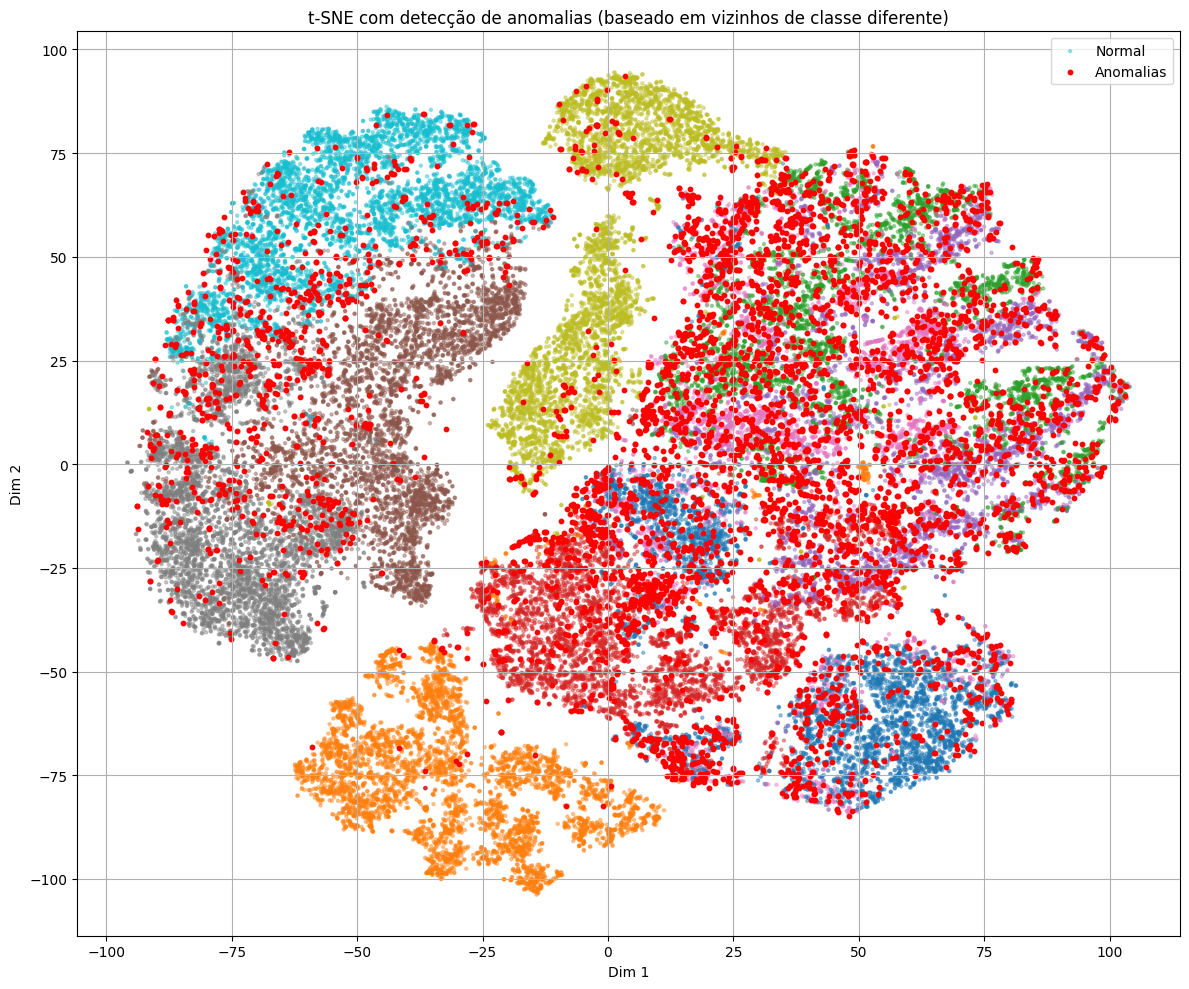

In [11]:
X = train_images.reshape(-1, 28*28) / 255.0
y = train_labels

# 2. Aplica t-SNE
print("Executando t-SNE... Isso pode demorar alguns minutos.")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

# 3. Encontra os 10 vizinhos mais próximos
print("Calculando vizinhos mais próximos...")
nbrs = NearestNeighbors(n_neighbors=11).fit(X_tsne)  # 11 porque o primeiro vizinho é ele mesmo
distances, indices = nbrs.kneighbors(X_tsne)

# 4. Verifica se os 10 vizinhos mais próximos têm uma classe diferente da atual
anomalies = []
for i in range(len(X_tsne)):
    neighbor_classes = y[indices[i][1:]]  # ignora o próprio ponto (índice 0)
    different_class_count = np.sum(neighbor_classes != y[i])
    if different_class_count >= 8:  # 8 de 10 vizinhos com classe diferente = anomalia
        anomalies.append(True)
    else:
        anomalies.append(False)

anomalies = np.array(anomalies)

# 5. Visualização
plt.figure(figsize=(12, 10))
plt.scatter(X_tsne[~anomalies, 0], X_tsne[~anomalies, 1], c=y[~anomalies], cmap='tab10', alpha=0.4, s=5, label="Normal")
plt.scatter(X_tsne[anomalies, 0], X_tsne[anomalies, 1], c='red', s=10, label="Anomalias")
plt.legend()
plt.title("t-SNE com detecção de anomalias (baseado em vizinhos de classe diferente)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.tight_layout()
plt.show()